In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/simranbharti03/about-health-data/early_wakeup_health_dataset.csv
/kaggle/input/datasets/simranbharti03/about-reduced/listings 2 reduced.csv


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("/kaggle/input/datasets/simranbharti03/about-health-data/early_wakeup_health_dataset.csv")

In [4]:
df.head(2)

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
0,P00001,76,Female,158.8,62.1,24.63,Italy,Entrepreneur,Widowed,08:59,...,Low,High,Medium,Medium,Low,87.3,Excellent,81.8,Excellent,No
1,P00002,49,Female,160.9,68.5,26.45,USA,Freelancer,Single,06:35,...,Medium,Medium,Medium,Low,Medium,72.0,Good,75.2,Good,No


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 64 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Person_ID                       10000 non-null  object 
 1   Age                             10000 non-null  int64  
 2   Gender                          10000 non-null  object 
 3   Height_cm                       10000 non-null  float64
 4   Weight_kg                       10000 non-null  float64
 5   BMI                             10000 non-null  float64
 6   Country                         10000 non-null  object 
 7   Occupation                      10000 non-null  object 
 8   Marital_Status                  10000 non-null  object 
 9   Wake_Up_Time                    10000 non-null  object 
 10  Sleep_Time                      10000 non-null  object 
 11  Sleep_Duration_Hours            10000 non-null  float64
 12  Sleep_Quality_Score             1

In [6]:
print(df.describe())

              Age     Height_cm    Weight_kg           BMI  \
count  10000.0000  10000.000000  10000.00000  10000.000000   
mean      44.6667    168.649160     73.10734     25.626963   
std       17.5172      9.876706     16.29195      4.870317   
min       18.0000    145.000000     33.60000     16.000000   
25%       29.7500    161.400000     61.30000     22.170000   
50%       43.0000    168.200000     72.00000     25.580000   
75%       58.0000    175.500000     83.50000     28.862500   
max       80.0000    205.500000    166.60000     44.560000   

       Sleep_Duration_Hours  Sleep_Quality_Score  Number_of_Night_Awakenings  \
count          10000.000000         10000.000000                10000.000000   
mean               7.229332             6.020190                    0.839100   
std                1.118486             1.585689                    0.936215   
min                4.000000             1.000000                    0.000000   
25%                6.470000             4

In [7]:
print(df.isnull().sum())

Person_ID              0
Age                    0
Gender                 0
Height_cm              0
Weight_kg              0
                      ..
Health_Score           0
Fitness_Level          0
Healthy_Aging_Score    0
Wellness_Category      0
Early_Waker            0
Length: 64, dtype: int64


# Inspect Columns

In [8]:
# List all column names
print(df.columns)

Index(['Person_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI',
       'Country', 'Occupation', 'Marital_Status', 'Wake_Up_Time', 'Sleep_Time',
       'Sleep_Duration_Hours', 'Sleep_Quality_Score',
       'Number_of_Night_Awakenings', 'Weekend_Sleep_Difference_Hours',
       'Nap_Frequency_Per_Week', 'Screen_Time_Before_Bed_Hours',
       'Exercise_Frequency_Per_Week', 'Exercise_Duration_Minutes',
       'Exercise_Type', 'Daily_Steps', 'Morning_Workout', 'Workout_Intensity',
       'Gym_Member', 'Daily_Calorie_Intake', 'Water_Intake_Liters',
       'Fruit_Intake_Per_Day', 'Vegetable_Intake_Per_Day',
       'Protein_Intake_Grams', 'Sugary_Drinks_Per_Week',
       'Fast_Food_Meals_Per_Week', 'Breakfast_Regularity_Score',
       'Smoking_Status', 'Alcohol_Consumption', 'Stress_Level',
       'Working_Hours_Per_Day', 'Sitting_Hours_Per_Day', 'Outdoor_Time_Hours',
       'Social_Interaction_Score', 'Meditation_Practice', 'Resting_Heart_Rate',
       'Systolic_BP', 'Diastolic_BP', 'Cho

# Explore Each Column

In [9]:
# Look at unique values for categorical columns
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()[:10]}")  # show first 10 unique values

# Look at distributions for numeric columns
print(df.describe())

Person_ID: ['P00001' 'P00002' 'P00003' 'P00004' 'P00005' 'P00006' 'P00007' 'P00008'
 'P00009' 'P00010']
Gender: ['Female' 'Male' 'Non-binary']
Country: ['Italy' 'USA' 'Mexico' 'Australia' 'India' 'Canada' 'Brazil' 'UK'
 'France' 'Nigeria']
Occupation: ['Entrepreneur' 'Freelancer' 'Nurse' 'Laborer' 'Software Engineer'
 'Accountant' 'Retired' 'Manager' 'Artist' 'Lawyer']
Marital_Status: ['Widowed' 'Single' 'Married' 'Divorced']
Wake_Up_Time: ['08:59' '06:35' '07:31' '08:36' '07:07' '07:50' '06:49' '06:11' '06:54'
 '07:06']
Sleep_Time: ['01:29' '02:25' '02:24' '01:19' '01:20' '01:05' '23:48' '00:30' '00:22'
 '00:41']
Exercise_Type: ['Weight Training' 'Walking' nan 'Running' 'Cycling' 'Yoga' 'HIIT'
 'Sports' 'Swimming']
Morning_Workout: ['No' 'Yes']
Workout_Intensity: ['Low' 'Moderate' nan 'High']
Gym_Member: ['Yes' 'No']
Smoking_Status: ['Former' 'Current' 'Never']
Alcohol_Consumption: ['Moderate' nan 'Light' 'Heavy']
Meditation_Practice: ['Yes' 'No']
Obesity_Risk: ['Low' 'Medium' 'High']

# Clean Data

In [10]:
# Handle missing values
df = df.dropna()  # or use df.fillna(value)

In [11]:
# Remove duplicates
df = df.drop_duplicates()

In [14]:
#Convert time columns if needed
df['Wake_Up_Time'] = pd.to_datetime(df['Wake_Up_Time'], errors='coerce')

/tmp/ipykernel_58/3493415524.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Wake_Up_Time'] = pd.to_datetime(df['Wake_Up_Time'], errors='coerce')


In [15]:
print(df['Wake_Up_Time'].head(10))

0    2026-06-16 08:59:00
3    2026-06-16 08:36:00
6    2026-06-16 06:49:00
7    2026-06-16 06:11:00
8    2026-06-16 06:54:00
9    2026-06-16 07:06:00
10   2026-06-16 05:49:00
11   2026-06-16 07:16:00
13   2026-06-16 06:13:00
14   2026-06-16 04:06:00
Name: Wake_Up_Time, dtype: datetime64[ns]


In [16]:
# Parse with full date + time format
df['Wake_Up_Time'] = pd.to_datetime(
    df['Wake_Up_Time'], 
    format='%Y-%m-%d %H:%M:%S', 
    errors='coerce'
)


# Extract Useful Features

In [17]:
# Extract hour, minute, and day
df['Wake_Hour'] = df['Wake_Up_Time'].dt.hour
df['Wake_Minute'] = df['Wake_Up_Time'].dt.minute
df['Wake_Day'] = df['Wake_Up_Time'].dt.day_name()


# Wake-Up Hour Trends

Wake_Hour
4     76.020640
5     76.463280
6     75.437826
7     74.584391
8     74.395770
9     73.257669
10    73.435088
11    75.116667
Name: Health_Score, dtype: float64


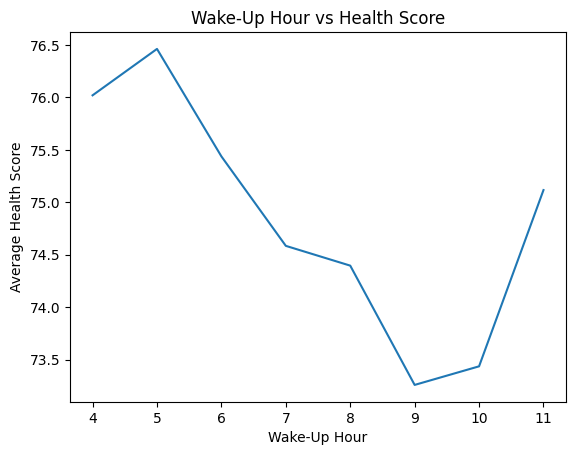

In [18]:
# Average health score by wake-up hour
hourly_health = df.groupby('Wake_Hour')['Health_Score'].mean()
print(hourly_health)

# Quick visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=hourly_health.index, y=hourly_health.values)
plt.xlabel("Wake-Up Hour")
plt.ylabel("Average Health Score")
plt.title("Wake-Up Hour vs Health Score")
plt.show()


# Weekday vs Weekend Patterns

Is_Weekend
False    75.198973
Name: Health_Score, dtype: float64


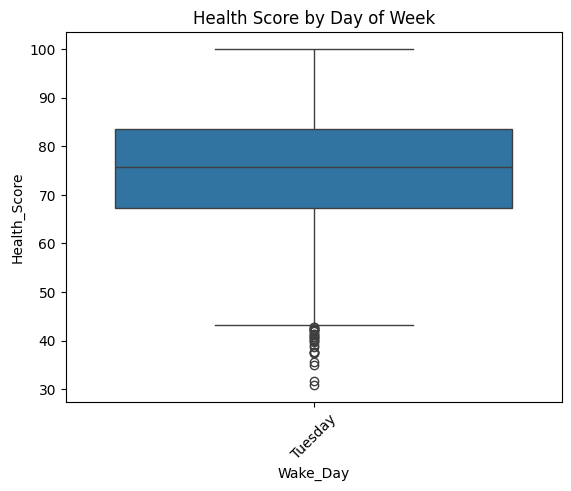

In [19]:
# Compare weekdays vs weekends
df['Is_Weekend'] = df['Wake_Day'].isin(['Saturday','Sunday'])
weekend_health = df.groupby('Is_Weekend')['Health_Score'].mean()
print(weekend_health)

sns.boxplot(x='Wake_Day', y='Health_Score', data=df)
plt.xticks(rotation=45)
plt.title("Health Score by Day of Week")
plt.show()


This highlights differences between weekday and weekend wake-up habits.

# Sleep Duration Impact

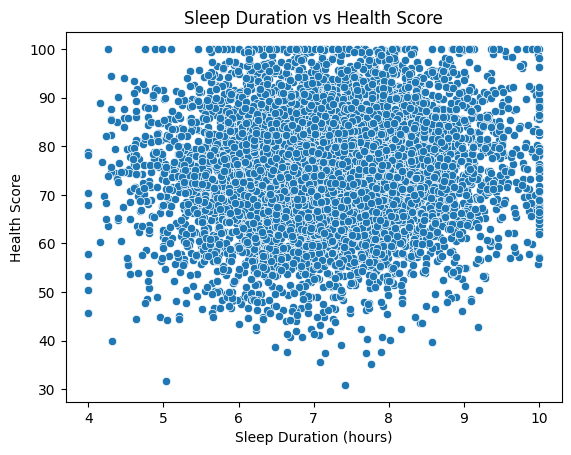

In [23]:
sns.scatterplot(x='Sleep_Duration_Hours', y='Health_Score', data=df)
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Health Score")
plt.title("Sleep Duration vs Health Score")
plt.show()

In [27]:
# Drop Person_ID since it's just an identifier
df = df.drop(columns=['Person_ID'])

In [28]:
# Confirm Numeric Columns
print(df.select_dtypes(include=['int64','float64']).columns)

Index(['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Sleep_Duration_Hours',
       'Sleep_Quality_Score', 'Number_of_Night_Awakenings',
       'Weekend_Sleep_Difference_Hours', 'Nap_Frequency_Per_Week',
       'Screen_Time_Before_Bed_Hours', 'Exercise_Frequency_Per_Week',
       'Exercise_Duration_Minutes', 'Daily_Steps', 'Daily_Calorie_Intake',
       'Water_Intake_Liters', 'Fruit_Intake_Per_Day',
       'Vegetable_Intake_Per_Day', 'Protein_Intake_Grams',
       'Sugary_Drinks_Per_Week', 'Fast_Food_Meals_Per_Week',
       'Breakfast_Regularity_Score', 'Stress_Level', 'Working_Hours_Per_Day',
       'Sitting_Hours_Per_Day', 'Outdoor_Time_Hours',
       'Social_Interaction_Score', 'Resting_Heart_Rate', 'Systolic_BP',
       'Diastolic_BP', 'Cholesterol_Level', 'Blood_Sugar_Level',
       'Energy_Level_Score', 'Fatigue_Level_Score', 'Immune_Health_Score',
       'Mood_Score', 'Anxiety_Score', 'Depression_Risk_Score',
       'Productivity_Score', 'Focus_Concentration_Score',
       'Life_Satis

In [30]:
# Convert Sleep Duration to Numeric
df['Sleep_Duration_Hours'] = pd.to_numeric(df['Sleep_Duration_Hours'], errors='coerce')

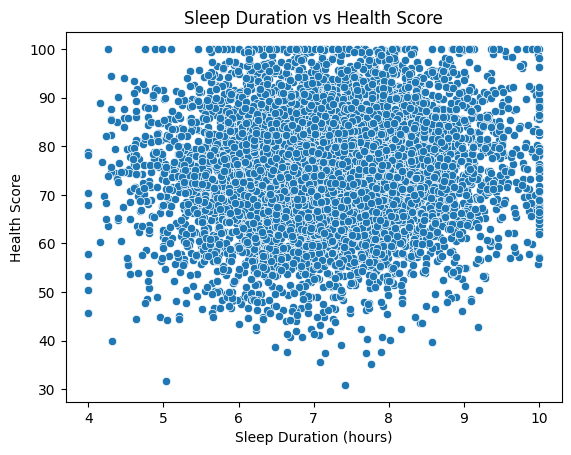

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Sleep_Duration_Hours', y='Health_Score', data=df)
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Health Score")
plt.title("Sleep Duration vs Health Score")
plt.show()


# Predictive Modeling

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [33]:
X = df[['Wake_Hour','Sleep_Duration_Hours','Exercise_Frequency_Per_Week','BMI']]
y = df['Health_Score']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [36]:
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)
print("R^2 score:", model.score(X_test, y_test))

Model coefficients: [-0.57158554  0.95130763  3.44490124 -1.207171  ]
Model intercept: 89.96150003623752
R^2 score: 0.48533285676646


# Lifestyle Factors vs Health

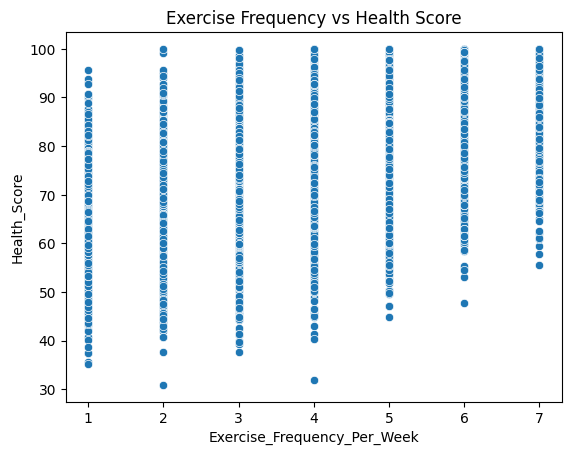

In [37]:
sns.scatterplot(x='Exercise_Frequency_Per_Week', y='Health_Score', data=df)
plt.title("Exercise Frequency vs Health Score")
plt.show()

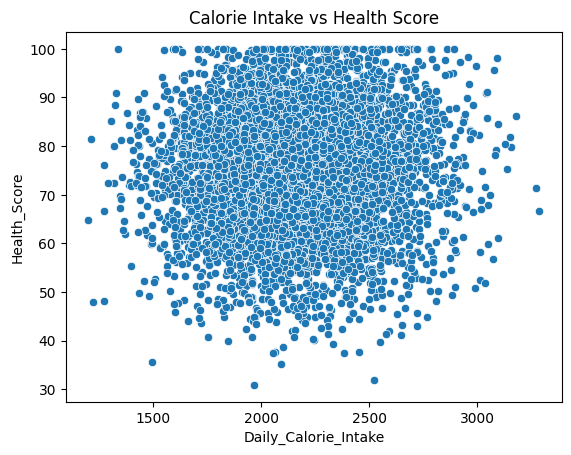

In [38]:
sns.scatterplot(x='Daily_Calorie_Intake', y='Health_Score', data=df)
plt.title("Calorie Intake vs Health Score")
plt.show()

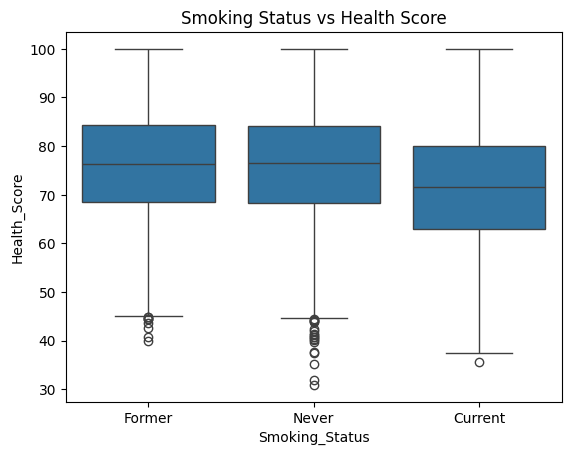

In [39]:
sns.boxplot(x='Smoking_Status', y='Health_Score', data=df)
plt.title("Smoking Status vs Health Score")
plt.show()

# Stress & Productivity

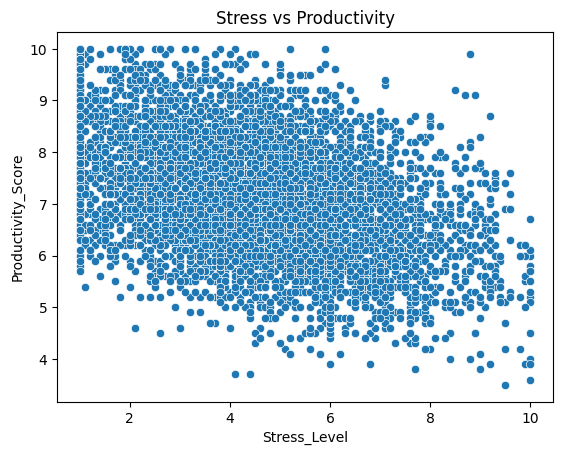

In [40]:
sns.scatterplot(x='Stress_Level', y='Productivity_Score', data=df)
plt.title("Stress vs Productivity")
plt.show()

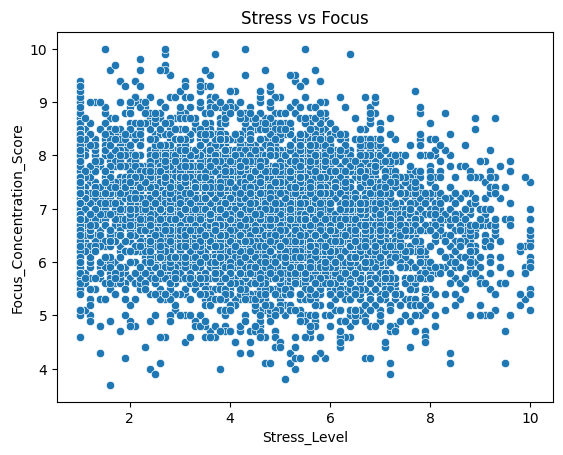

In [41]:
sns.scatterplot(x='Stress_Level', y='Focus_Concentration_Score', data=df)
plt.title("Stress vs Focus")
plt.show()

# Mental Health Indicators

In [42]:
# Look at anxiety, depression risk, and mood.

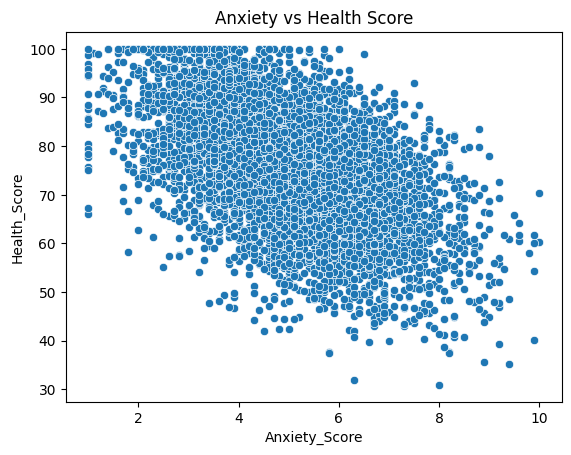

In [43]:
sns.scatterplot(x='Anxiety_Score', y='Health_Score', data=df)
plt.title("Anxiety vs Health Score")
plt.show()

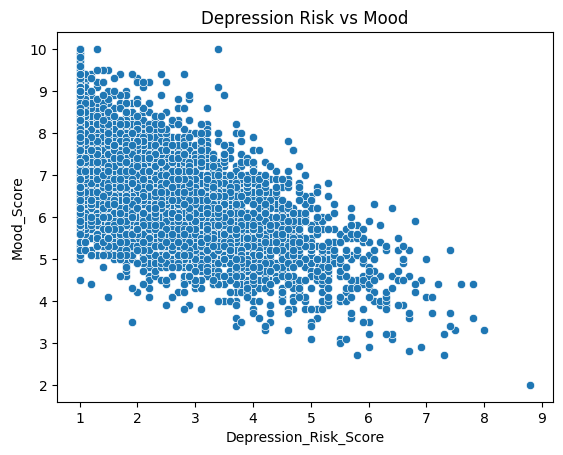

In [44]:
sns.scatterplot(x='Depression_Risk_Score', y='Mood_Score', data=df)
plt.title("Depression Risk vs Mood")
plt.show()

# Cardiovascular & Fitness

In [45]:
# Check blood pressure, cholesterol, and fitness levels.

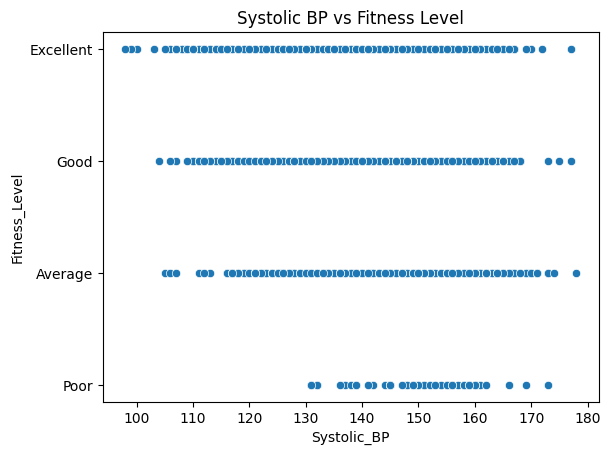

In [46]:
sns.scatterplot(x='Systolic_BP', y='Fitness_Level', data=df)
plt.title("Systolic BP vs Fitness Level")
plt.show()

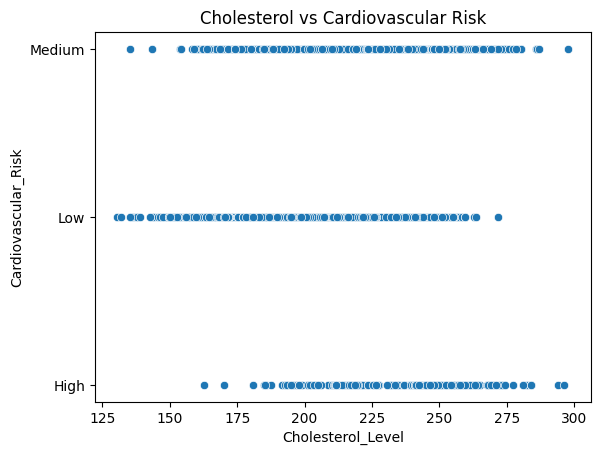

In [47]:
sns.scatterplot(x='Cholesterol_Level', y='Cardiovascular_Risk', data=df)
plt.title("Cholesterol vs Cardiovascular Risk")
plt.show()

# Wellness Categories

In [49]:
# Compare overall wellness categories.

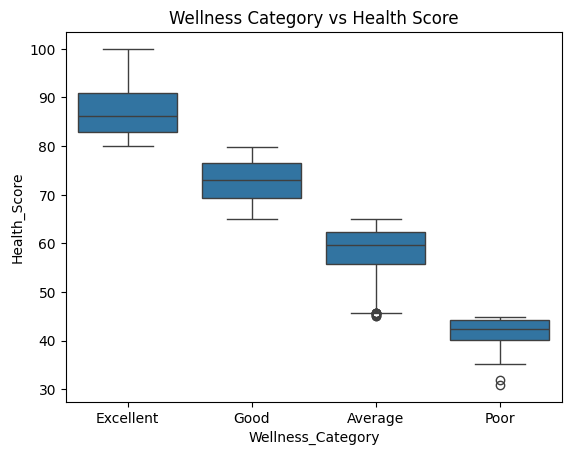

In [50]:
sns.boxplot(x='Wellness_Category', y='Health_Score', data=df)
plt.title("Wellness Category vs Health Score")
plt.show()

# BMI vs Health Outcomes

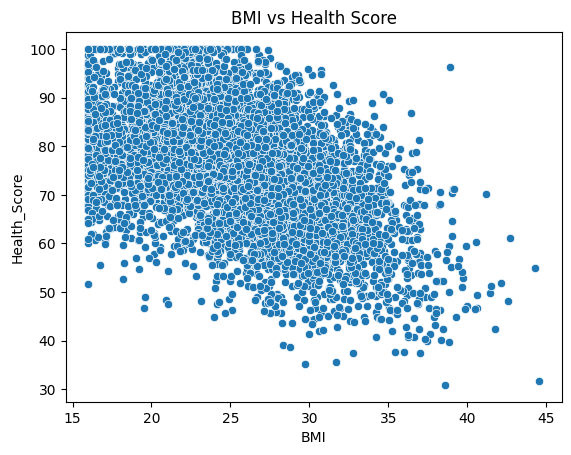

In [51]:
sns.scatterplot(x='BMI', y='Health_Score', data=df)
plt.title("BMI vs Health Score")
plt.show()

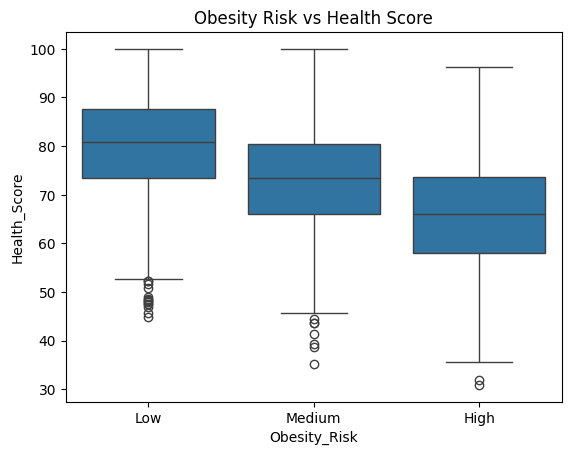

In [52]:
sns.boxplot(x='Obesity_Risk', y='Health_Score', data=df)
plt.title("Obesity Risk vs Health Score")
plt.show()

In [53]:
# This shows how body composition relates to health scores and obesity risk.

# Country Comparisons

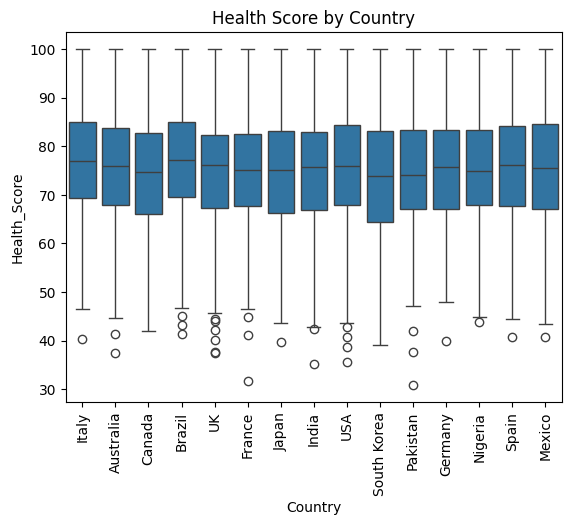

In [54]:
sns.boxplot(x='Country', y='Health_Score', data=df)
plt.xticks(rotation=90)
plt.title("Health Score by Country")
plt.show()

# Wellness Category Breakdown

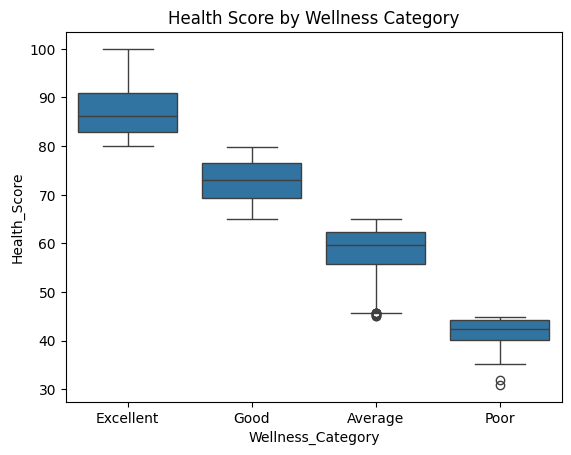

In [55]:
sns.boxplot(x='Wellness_Category', y='Health_Score', data=df)
plt.title("Health Score by Wellness Category")
plt.show()

 # ✨ Big Picture

# The data tells a clear story: health thrives on harmony. Early rising, consistent sleep, balanced nutrition, regular exercise, stress management, and social connection together create the strongest outcomes across physical, mental, and emotional well-being.

- It’s not about perfection in one area — it’s about weaving small, steady habits into a lifestyle that sustains energy, focus, and joy.